# Marigold horizontal leafs detector by using the sacred framework 

## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np

for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "src" / "science_jubilee").is_dir():
        REPO_ROOT = parent
        break
else:
    raise RuntimeError("Could not locate the science_jubilee repository root")

SRC_ROOT = REPO_ROOT / "src"
for path in (SRC_ROOT, REPO_ROOT):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)


from science_jubilee.machine_session import MachineSession
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.filter_scene import run_filter_scene
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.inference_marigold import run_infer_depths_and_normals
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.target_horizontals import run_estimate_horizontal_targets
from science_jubilee.Vision.Marigold_Horizontal_leafs.ingredients.reconstruction import run_create_point_cloud
import imageio

DETECTOR_ROOT = SRC_ROOT / "science_jubilee/Vision/Marigold_Horizontal_leafs"
IMAGE_DIR = DETECTOR_ROOT / "input"
OUTPUT_DIR = DETECTOR_ROOT / "output/latest"
CONFIG_PATH = DETECTOR_ROOT / "config.yaml"
IMAGE_PATH = IMAGE_DIR / "latest.jpg"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
STEPS =100
RUN_RECONSTRUCTION = False
TARGET_AUTO = False

def show(image, title=""):
    image_array = np.asarray(image)
    display_image = image_array if image_array.ndim == 3 else image_array
    plt.figure(figsize=(10, 7))
    plt.imshow(display_image, cmap="gray" if image_array.ndim == 2 else None)
    plt.title(title)
    plt.axis("off")
    plt.show()
    
hardware=True


c:\Users\Justin\.conda\envs\marigold_env\lib\site-packages\sacred\dependencies.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 2. Capture the latest image (optional hardware step)

In [2]:
import time

if hardware:
    env = ".env.hardware"
else:
    env = ".env.mock"
    
session = MachineSession.from_env(env)
cam = session.camera
    
# move camera to imaging position and capture
X_DEPART, Y_DEPART, Z_DEPART = 130.0, 150.0, 320.0
if hardware == False:
    cam._image =  imageio.imread("input/test.png")
else:
    
    cam.move_to_get_image(X_DEPART, Y_DEPART, Z_DEPART)

image = cam.get_image()

cv2.imwrite(str(IMAGE_PATH), image)
print(f"Saved {IMAGE_PATH}")

Saved c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\input\latest.jpg


## 3. Load and inspect the image

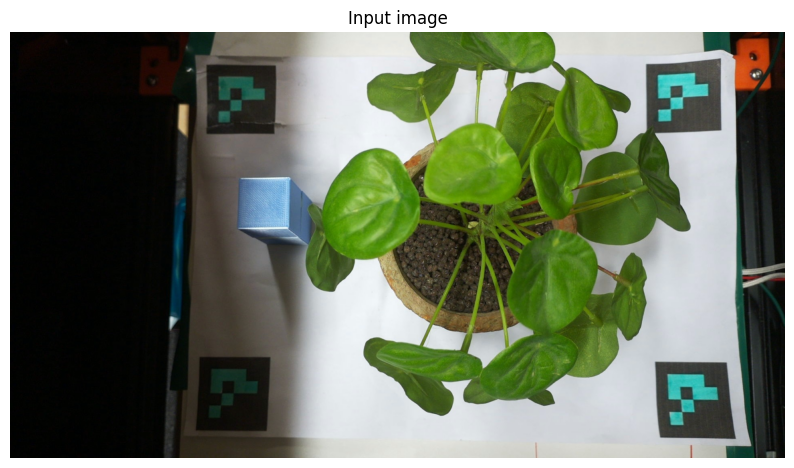

In [3]:
image = cv2.imread(str(IMAGE_PATH))
if image is None:
    raise FileNotFoundError(f"Unable to read {IMAGE_PATH}")
show(image, "Input image")

## 4. Segment the tray and plant

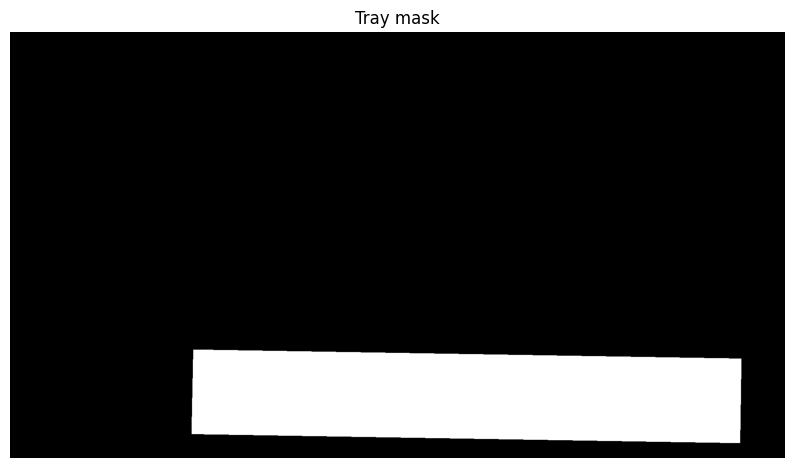

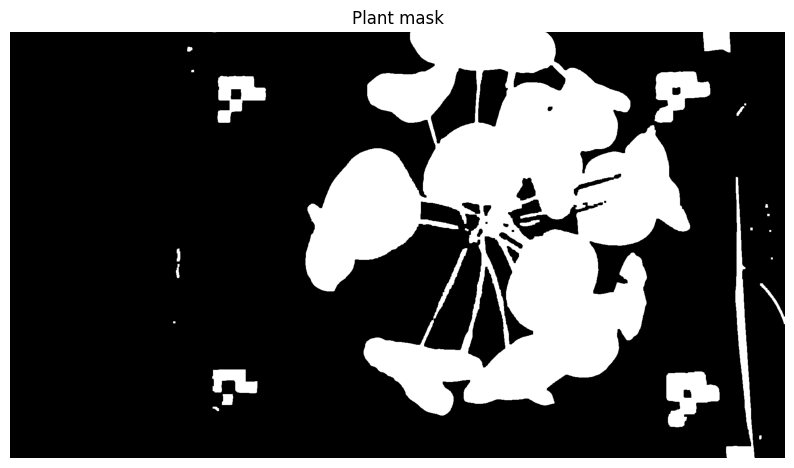

In [4]:
filtered = run_filter_scene(image=image)
show(filtered["tray_mask"], "Tray mask")
show(filtered["plant_mask"], "Plant mask")

## 5. Estimate depth and surface normals

[+] Using device: cuda
[+] Loading Marigold depth and normal models...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

...

Diffusion steps...:   0%|          | 0/100 [00:00<?, ?it/s]

[+] Running normal estimation...


Marigold predictions...:   0%|          | 0/1 [00:00<?, ?it/s]

Diffusion steps...:   0%|          | 0/100 [00:00<?, ?it/s]

[+] Depth saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_depth.npy
[+] Normals saved to: c:\Users\Justin\Desktop\Jubilee\science_jubilee\src\science_jubilee\Vision\Marigold_Horizontal_leafs\output\latest\latest_normals.npy
Depth shape: (1056, 1920, 1)
Normals shape: (1056, 1920, 3)


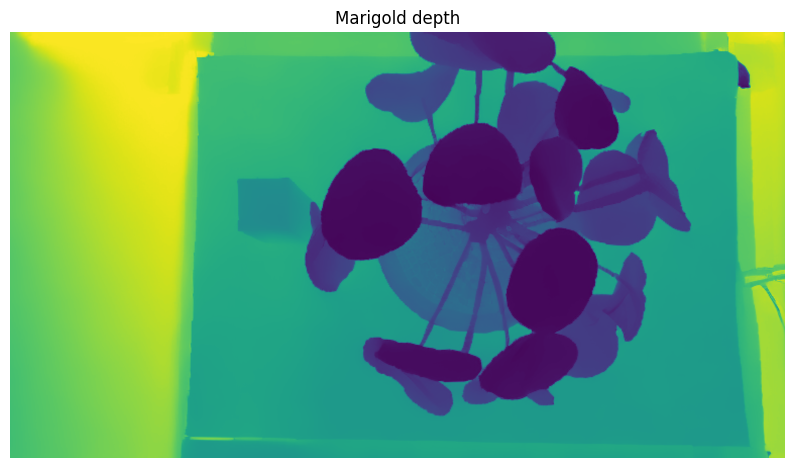

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


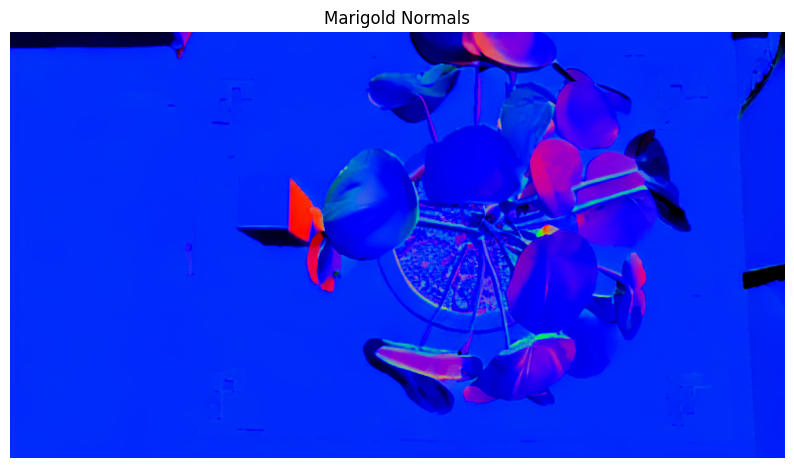

In [5]:
inference = run_infer_depths_and_normals(
    image=image,
    output_dir=str(OUTPUT_DIR),
    steps=STEPS,
    image_name=IMAGE_PATH.name,
)
depth_map = inference["depth"]
normals = inference["normals"]
print("Depth shape:", depth_map.shape)
print("Normals shape:", normals.shape)
show(depth_map, "Marigold depth")
show(normals,"Marigold Normals" )

## 6. Detect horizontal leaf targets

[+] Tray depth values: 637340 pixels, min=0.00, max=0.99
[+] Depth map scaled convert to mm (tray_z_mm=320.0), depth_max_mm=320.00) and depth_min_mm=165.17
Targets detected: 3


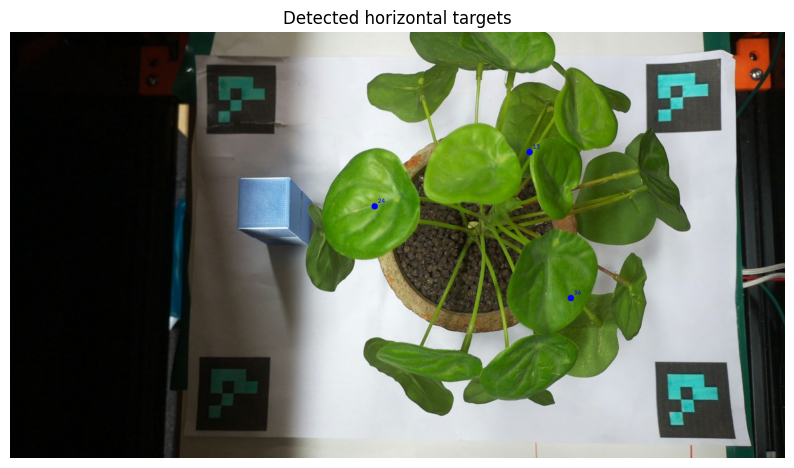

In [6]:
import yaml
with open(CONFIG_PATH, "r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle) or {}
targets_result = run_estimate_horizontal_targets(
    image=image,
    depth_map=depth_map,
    normals=normals,
    config=config,
    output_dir=str(OUTPUT_DIR),
    image_name=IMAGE_PATH.name,
)
targets = targets_result["targets"]
overlay = targets_result["overlay"]
print(f"Targets detected: {len(targets)}")
show(overlay, "Detected horizontal targets")

## 7. Select a target

In [7]:
if not targets:
    raise RuntimeError("No horizontal targets detected; inspect the masks or rerun inference.")
if TARGET_AUTO:
    target = max(targets, key=lambda item: -item["xyz_mm"][2])
else:
    for index, candidate in enumerate(targets):
        print(index, candidate)
        print("Select a target among the above list")

0 {'id': 13, 'pixel': [1287, 299], 'area_px': 108368, 'bbox': [997, 98, 668, 477], 'extent': 1.40041928721174, 'normal_confidence': 0.986831545829773, 'depth_std_mm': 2.9020303849675106, 'xyz_mm': [42.1118278503418, -30.701278686523438, 191.26220703125], 'normal': [-0.059235528111457825, 0.15051500499248505, 0.986831545829773]}
Select a target among the above list
1 {'id': 24, 'pixel': [903, 433], 'area_px': 38202, 'bbox': [801, 290, 209, 275], 'extent': 1.3157894736842106, 'normal_confidence': 0.997291624546051, 'depth_std_mm': 0.006893186516353869, 'xyz_mm': [-7.37278938293457, -11.627455711364746, 168.367919921875], 'normal': [-0.009340452030301094, 0.07295320183038712, 0.997291624546051]}
Select a target among the above list
2 {'id': 36, 'pixel': [1389, 660], 'area_px': 109395, 'bbox': [1117, 390, 493, 523], 'extent': 1.0608519269776877, 'normal_confidence': 0.9740668535232544, 'depth_std_mm': 0.026365782540994614, 'xyz_mm': [48.90890884399414, 14.505942344665527, 168.5807800292968

In [ ]:
target = targets[2]  #your target choice
print("Selected target:", target)
print(target['xyz_mm'])


Selected target: 2


TypeError: 'int' object is not subscriptable

## 8. Move into the target

In [ ]:
supplementary_offset_xyz = [
        -10.0,
        15.0,
        0,
    ]
# On se déplace vers le target en gardant la même hauteur
if hardware:    
    nav= session.free_navigator
    nav.move_to(
        x=X_DEPART + target["xyz_mm"][0] + cam.offset[0]+supplementary_offset_xyz[0],
        y=Y_DEPART - target["xyz_mm"][1] + cam.offset[1]+ supplementary_offset_xyz[1],
        speed=3000.0,
        wait=True,
    )
    nav.move_to(
        z=Z_DEPART + cam.offset[2] - target["xyz_mm"][2] - 5+supplementary_offset_xyz[2], speed=1000.0, wait=True
    )

## 8. Create Point cloud from depth